Load training data 

In [ ]:
import pickle as pkl
import os

all_data = []
duration = 60.0  # Duration used when collecting data

for left_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for right_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        for servo_std in [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]:
            filename = f"noisy_training_data/noisy_spiral_{left_std}_{right_std}_{servo_std}_{duration}s.pkl"
            
            # Check if file exists before loading
            if os.path.exists(filename):
                try:
                    data = pkl.load(open(filename, "rb"))
                    all_data.extend(data)
                    print(f"Loaded {len(data)} tuples from {filename}")
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
            else:
                print(f"File not found: {filename}")

print(f"\nTotal data tuples collected: {len(all_data)}")

Error loading noisy_training_data/noisy_spiral_0.0_0.0_0.0_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.0_0.3_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.0_0.6_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.0_0.9_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.0_1.2_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.0_1.5_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.1_0.0_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.1_0.3_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.1_0.6_60.0s.pkl: No module named 'numpy._core'
Error loading noisy_training_data/noisy_spiral_0.0_0.1_0.9_60.0s.pkl: No module named 'numpy._core'


Main experiment block 

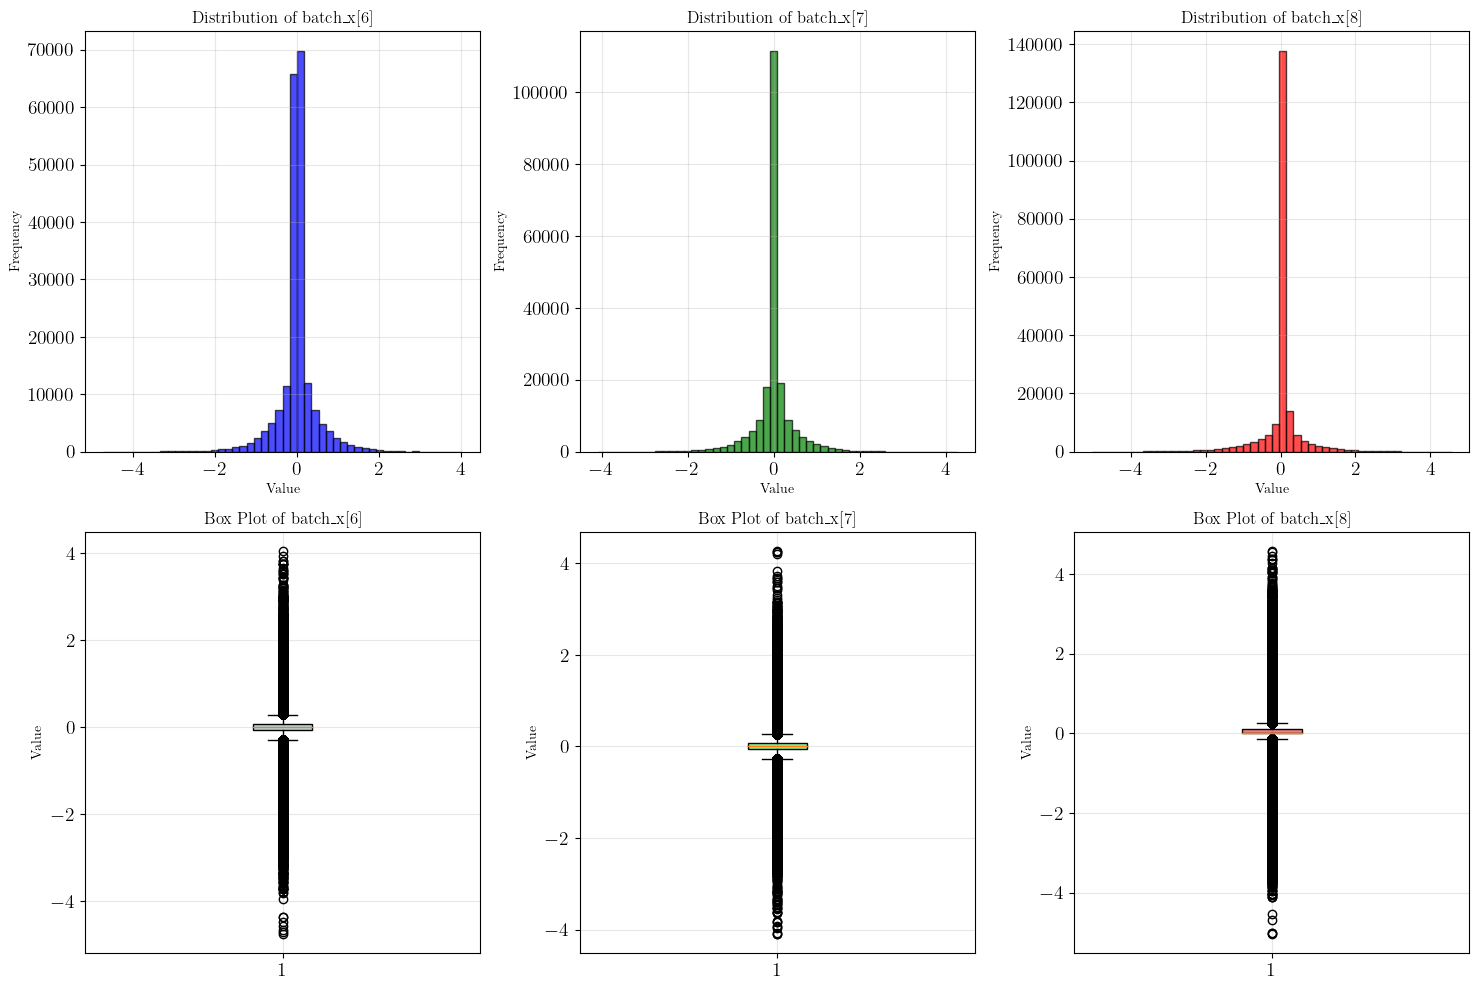

Statistics for batch_x features:
batch_x[6] - Mean: -0.0008, Std: 0.4577, Min: -4.7466, Max: 4.0411
batch_x[7] - Mean: 0.0013, Std: 0.4454, Min: -4.0929, Max: 4.2576
batch_x[8] - Mean: 0.0015, Std: 0.5453, Min: -5.0401, Max: 4.5694


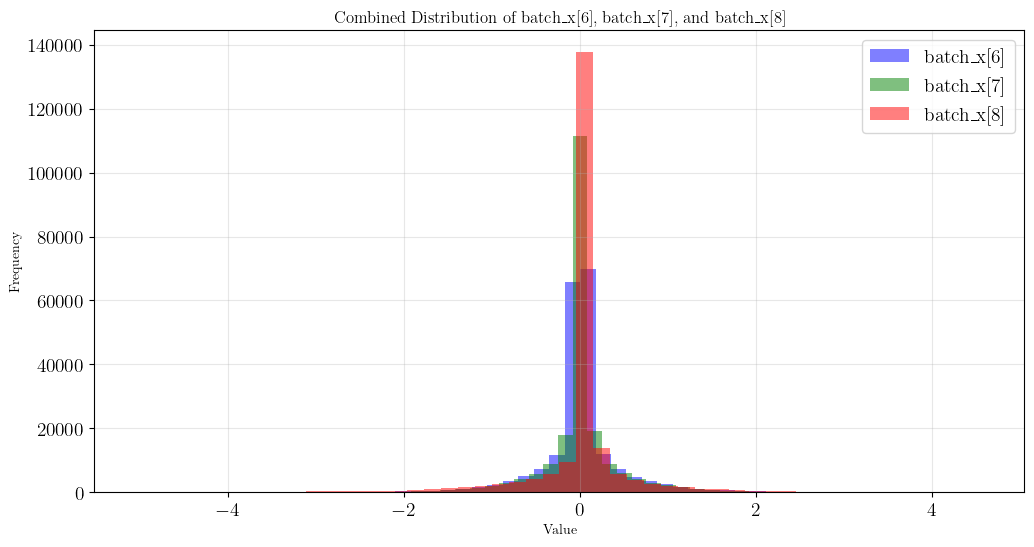

In [5]:
# Plot distributions of batch_x[6], batch_x[7], and batch_x[8]
import matplotlib.pyplot as plt
import numpy as np

# ----- Offline training (supervised next-step regression) -----
batch_x_list = []
batch_y_list = []
# ftau_rpy_0.05_straight_line_x_2
for tr in rpy_0_05_combined_replay_buffer:
# for tr in sinusoidal_y_fixed_x_replay_buffer:
    obs, action, next_obs, reward, terminate, truncated = tr
    obs_tensor = torch.from_numpy(obs).float()
    action_tensor = torch.tensor(action).float()
    next_obs_tensor = torch.from_numpy(next_obs).float()
        
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)



# Convert to tensors with correct dimensions
batch_x = torch.stack(batch_x_list, dim=0)  # shape: [B, 14]
batch_y = torch.stack(batch_y_list, dim=0)

# Extract the data for plotting
feature_6 = batch_x[:, 0].cpu().numpy()
feature_7 = batch_x[:, 1].cpu().numpy()
feature_8 = batch_x[:, 2].cpu().numpy()

# Create subplots for distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot histograms
axes[0, 0].hist(feature_6, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Distribution of batch_x[6]')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(feature_7, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Distribution of batch_x[7]')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(feature_8, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 2].set_title('Distribution of batch_x[8]')
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Plot box plots
axes[1, 0].boxplot(feature_6, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Box Plot of batch_x[6]')
axes[1, 0].set_ylabel('Value')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot(feature_7, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1, 1].set_title('Box Plot of batch_x[7]')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].boxplot(feature_8, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1, 2].set_title('Box Plot of batch_x[8]')
axes[1, 2].set_ylabel('Value')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Statistics for batch_x features:")
print(f"batch_x[6] - Mean: {np.mean(feature_6):.4f}, Std: {np.std(feature_6):.4f}, Min: {np.min(feature_6):.4f}, Max: {np.max(feature_6):.4f}")
print(f"batch_x[7] - Mean: {np.mean(feature_7):.4f}, Std: {np.std(feature_7):.4f}, Min: {np.min(feature_7):.4f}, Max: {np.max(feature_7):.4f}")
print(f"batch_x[8] - Mean: {np.mean(feature_8):.4f}, Std: {np.std(feature_8):.4f}, Min: {np.min(feature_8):.4f}, Max: {np.max(feature_8):.4f}")

# Combined distribution plot
plt.figure(figsize=(12, 6))
plt.hist(feature_6, bins=50, alpha=0.5, label='batch_x[6]', color='blue')
plt.hist(feature_7, bins=50, alpha=0.5, label='batch_x[7]', color='green')
plt.hist(feature_8, bins=50, alpha=0.5, label='batch_x[8]', color='red')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Combined Distribution of batch_x[6], batch_x[7], and batch_x[8]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
import torch
from mbrl.models.saviolo_et_al_mlp import DiscreteQuadDynamicsNN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sav_model = DiscreteQuadDynamicsNN()
sav_model.to(device)
# sav_model.load_model("trained_savmodel/combined_rw.pth")
# print(sav_model)

c:\users\ksubh\onedrive\documents\swarmslab_rl\summer 25\implementations\mbrl_lib_maintained\mbrl-lib-experiments\mbrl\models\saviolo_et_al_mlp.py:204: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this

In [5]:
# ----- Preparing training data -----
batch_x_list = []
batch_y_list = []
for tr in rpy_0_05_combined_replay_buffer:
# for tr in sinusoidal_y_fixed_x_replay_buffer:
    obs, action, next_obs, reward, terminate, truncated = tr
    obs_tensor = torch.from_numpy(obs).float()
    action_tensor = torch.tensor(action).float()
    next_obs_tensor = torch.from_numpy(next_obs).float()
        
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)



# Convert to tensors with correct dimensions
batch_x = torch.stack(batch_x_list, dim=0)  # shape: [B, 14]
batch_y = torch.stack(batch_y_list, dim=0)
# batch_x = batch_x.double()
# batch_y = batch_y.double()

# Move data to GPU
batch_x = batch_x.to(device)  # (B, 13)
batch_y = batch_y.to(device)  # (B, 9)

# Compute dataset statistics
x_mean, x_std = batch_x.mean(dim=0), batch_x.std(dim=0)
y_mean, y_std = batch_y.mean(dim=0), batch_y.std(dim=0)



print("x_mean", x_mean, "x_std", x_std, "y_mean", y_mean, "y_std", y_std)

# Avoid division by zero
x_std = x_std.clamp_min(1e-8)
y_std = y_std.clamp_min(1e-8)

# sav_model.x_mean = x_mean
# sav_model.x_std = x_std
# sav_model.y_mean = y_mean
# sav_model.y_std = y_std
sav_model.attach_stats(x_mean, x_std, y_mean, y_std)

# sav_model.y_mean[7] = x_mean[7]
# sav_model.y_std[7] = x_std[7]

# Normalize
batch_x = (batch_x - x_mean) / x_std
batch_y = (batch_y - y_mean) / y_std



# ---- Split into train/val (post-normalization to keep your flow) ----
N = batch_x.shape[0]
perm = torch.randperm(N, device=batch_x.device)
N_val = max(1, int(0.1 * N))
val_idx = perm[:N_val]
train_idx = perm[N_val:]

batch_x_train = batch_x[train_idx]
batch_y_train = batch_y[train_idx]
batch_x_val   = batch_x[val_idx]
batch_y_val   = batch_y[val_idx]

# assert sav_model.x_mean.shape[0] == 13 and sav_model.y_mean.shape[0] == 9
# # sanity: round-trip
# y_norm = (batch_y - sav_model.y_mean) / sav_model.y_std
# y_back = y_norm * sav_model.y_std + sav_model.y_mean
# print("max |y - y_back| =", (y_back - batch_y).abs().max().item())

x_mean tensor([-8.4382e-04,  1.2602e-03,  1.4876e-03,  2.0312e-05, -2.2994e-04,
         1.5223e-02,  2.7752e-04,  3.1549e-04,  7.8958e-04,  3.2668e+00,
        -2.4045e-05,  3.4384e-07, -1.0671e-05], device='cuda:0') x_std tensor([0.4577, 0.4454, 0.5454, 0.0855, 0.0867, 2.0692, 0.3038, 0.3050, 0.0851,
        0.5368, 0.0468, 0.0026, 0.0057], device='cuda:0') y_mean tensor([-8.6940e-04,  1.3510e-03,  1.4324e-03,  3.1150e-05, -2.0832e-04,
         1.5155e-02,  1.7346e-04,  1.7052e-04,  7.9189e-04], device='cuda:0') y_std tensor([0.4578, 0.4455, 0.5450, 0.0855, 0.0866, 2.0692, 0.3037, 0.3042, 0.0848],
       device='cuda:0')


In [6]:
# ----- Training -----

opt = torch.optim.Adam(sav_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=25, min_lr=1e-9, verbose=True
)

batch_size = 1024

def compute_validation_loss():
    sav_model.eval()
    with torch.no_grad():
        Nval = batch_x_val.shape[0]
        total, count = 0.0, 0
        for s in range(0, Nval, batch_size):
            e = min(s + batch_size, Nval)
            stats = sav_model.supervised_step(batch_x_val[s:e], batch_y_val[s:e], None)
            bsz = e - s
            total += stats["loss"] * bsz   # assume mean loss returned
            count += bsz
        return total / max(1, count)

print("Starting training...")
for epoch in range(10000):  # paper reports ~20K epochs
    sav_model.train()

    # Shuffle train set
    Ntr = batch_x_train.shape[0]
    idx = torch.randperm(Ntr, device=batch_x_train.device)
    x_shuf = batch_x_train.index_select(0, idx)
    y_shuf = batch_y_train.index_select(0, idx)

    # Mini-batch training (NO tail drop + sample-weighted averaging)
    total_train, count_train = 0.0, 0
    for s in range(0, Ntr, batch_size):
        e = min(s + batch_size, Ntr)
        stats = sav_model.supervised_step(x_shuf[s:e], y_shuf[s:e], opt)
        bsz = e - s
        total_train += stats["loss"] * bsz
        rpy_loss = stats["lq"] * bsz
        lv_loss = stats["lv"] * bsz
        w_loss = stats["lw"] * bsz
        count_train += bsz
    avg_rpy_loss = rpy_loss / max(1, count_train)
    avg_lv_loss = lv_loss / max(1, count_train)
    avg_w_loss = w_loss / max(1, count_train)
    avg_train_loss = total_train / max(1, count_train)

    # Validation + scheduler
    val_loss = compute_validation_loss()
    scheduler.step(val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train {avg_train_loss:.9f} | lv {avg_lv_loss:.9f} | w {avg_w_loss:.9f} | rpy {avg_rpy_loss:.9f} | Val {val_loss:.6f} | "
              f"LR {opt.param_groups[0]['lr']:.2e}")

c:\Users\ksubh\anaconda3\envs\mquad_cuda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch    0 | Train 0.459138179 | lv 0.000047597 | w 0.000068446 | rpy 0.000130879 | Val 0.080251 | LR 1.00e-03
Epoch   50 | Train 0.039852146 | lv 0.000016050 | w 0.000029575 | rpy 0.000086562 | Val 0.041711 | LR 1.00e-03
Epoch  100 | Train 0.033052344 | lv 0.000015564 | w 0.000022037 | rpy 0.000053096 | Val 0.035643 | LR 1.00e-03
Epoch  150 | Train 0.029941629 | lv 0.000025624 | w 0.000031216 | rpy 0.000112106 | Val 0.033399 | LR 1.00e-03
Epoch  200 | Train 0.028110365 | lv 0.000018081 | w 0.000029906 | rpy 0.000058070 | Val 0.031240 | LR 1.00e-03
Epoch  250 | Train 0.026736608 | lv 0.000017815 | w 0.000026746 | rpy 0.000062318 | Val 0.029796 | LR 1.00e-03
Epoch  300 | Train 0.024675972 | lv 0.000019773 | w 0.000026493 | rpy 0.000046482 | Val 0.027903 | LR 5.00e-04
Epoch  350 | Train 0.023960901 | lv 0.000010439 | w 0.000026006 | rpy 0.000040701 | Val 0.027381 | LR 5.00e-04
Epoch  400 | Train 0.023572656 | lv 0.000011969 | w 0.000016561 | rpy 0.000067211 | Val 0.0

KeyboardInterrupt: 

In [7]:
sav_model.save_model("trained_savmodel/combined_rw.pth")

In [9]:
# Verify NN prediction pitch 
# replay_buffer = env.run_a_simulation_from_takeoff()
import pickle

# replay_buffer = 
with open('ftau_rpy_0.05/ftau_rpy_0.05_sinoidial_y_fixed_x_cutat_12000_09-08-2025-17-07-57.pkl', 'rb') as f:
    sinusoidal_y_fixed_x_replay_buffer = pickle.load(f)
    sinusoidal_y_fixed_x_replay_buffer = sinusoidal_y_fixed_x_replay_buffer.get_all()
    sinusoidal_y_fixed_x_replay_buffer = sinusoidal_y_fixed_x_replay_buffer[80100:80900]

pitch_actions = []
pitch_actual = []
pitch_predicted = []
time_steps = []
dpitch_actual = []
dpitch_predicted = []
time = 0

for transition in sinusoidal_y_fixed_x_replay_buffer:
    obs, action, next_obs, reward, terminate, truncated = transition
    dummy_model_state = {}
    dummy_model_state["obs"] = torch.tensor(obs).to(device).float()
    action = torch.tensor(action).to(device).float()
    next_observs_nn, _, _, next_dummy_model_state_nn = sav_model.sample(action, dummy_model_state)
    pitch_actions.append(action[1].item())
    pitch_actual.append(next_obs[6])
    dpitch_actual.append(next_obs[3])
    pitch_predicted.append(next_observs_nn[6].item())
    dpitch_predicted.append(next_observs_nn[3].item())
    time_steps.append(time)
    # print(pitch_actual[-1], pitch_predicted[-1])
    time += 0.05



# Plot pitch data against time
plt.figure(figsize=(15, 12))

# Plot pitch actions
plt.subplot(5, 1, 1)
plt.plot(time_steps, pitch_actions, 'b-', linewidth=1.5, label='Pitch Actions')
plt.ylabel('Pitch Actions')
plt.title('Pitch Actions vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot pitch actual
plt.subplot(5, 1, 2)
plt.plot(time_steps, pitch_actual, 'g-', linewidth=1.5, label='Actual Pitch')
plt.ylabel('Actual Pitch')
plt.title('Actual Pitch vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot pitch predicted
plt.subplot(5, 1, 3)
plt.plot(time_steps, pitch_predicted, 'r-', linewidth=1.5, label='Predicted Pitch')
plt.ylabel('Predicted Pitch')
plt.title('Predicted Pitch vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot dpitch actual
plt.subplot(5, 1, 4)
plt.plot(time_steps, dpitch_actual, 'g-', linewidth=1.5, label='Actual dPitch')
plt.ylabel('Actual dPitch')
plt.title('Actual Pitch Derivative vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot dpitch predicted
plt.subplot(5, 1, 5)
plt.plot(time_steps, dpitch_predicted, 'r-', linewidth=1.5, label='Predicted dPitch')
plt.ylabel('Predicted dPitch')
plt.xlabel('Time (s)')
plt.title('Predicted Pitch Derivative vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Combined plot for pitch comparison
plt.figure(figsize=(12, 6))
plt.plot(time_steps, pitch_actions, 'b-', linewidth=1.5, label='Pitch Actions', alpha=0.7)
plt.plot(time_steps, pitch_actual, 'g-', linewidth=1.5, label='Actual Pitch')
plt.plot(time_steps, pitch_predicted, 'r--', linewidth=1.5, label='Predicted Pitch')
plt.xlabel('Time (s)')
plt.ylabel('Pitch Value')
plt.title('Pitch Actions, Actual, and Predicted vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Combined plot for pitch derivatives
plt.figure(figsize=(12, 6))
plt.plot(time_steps, dpitch_actual, 'g-', linewidth=1.5, label='Actual dPitch')
plt.plot(time_steps, dpitch_predicted, 'r--', linewidth=1.5, label='Predicted dPitch')
plt.xlabel('Time (s)')
plt.ylabel('Pitch Derivative')
plt.title('Pitch Derivatives: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Data points collected: {len(time_steps)}")
print(f"Time range: {time_steps[0]:.2f}s to {time_steps[-1]:.2f}s")
print(f"Pitch actions range: {min(pitch_actions):.4f} to {max(pitch_actions):.4f}")
print(f"Actual pitch range: {min(pitch_actual):.4f} to {max(pitch_actual):.4f}")
print(f"Predicted pitch range: {min(pitch_predicted):.4f} to {max(pitch_predicted):.4f}")
print(f"Actual dPitch range: {min(dpitch_actual):.4f} to {max(dpitch_actual):.4f}")
print(f"Predicted dPitch range: {min(dpitch_predicted):.4f} to {max(dpitch_predicted):.4f}")


KeyboardInterrupt: 

In [10]:
# Load validation data to Validate NN predictions for all states
import pickle

# Load Validation data 
with open('ftau_rpy_0.05/ftau_rpy_0.05_sinoidial_z_fixed_xy_cutat_20_09-07-2025-19-40-57.pkl', 'rb') as f:
    sinusoidal_z_fixed_xy_replay_buffer = pickle.load(f)
    sinusoidal_z_fixed_xy_replay_buffer = sinusoidal_z_fixed_xy_replay_buffer.get_all()


dx_actual = []
dy_actual = []
dz_actual = []
droll_actual = []
dpitch_actual = []
dyaw_actual = []
roll_actual = []
pitch_actual = []
yaw_actual = []

dx_predicted = []
dy_predicted = []
dz_predicted = []
droll_predicted = []
dpitch_predicted = []
dyaw_predicted = []
roll_predicted = []
pitch_predicted = []
yaw_predicted = []

thrust = []
roll_action = []
pitch_action = []
yaw_action = []

time = 0
time_steps = []

validation_data = sinusoidal_x_fixed_y_replay_buffer[:500]


for transition in validation_data:
    obs, action, next_obs, reward, terminate, truncated = transition
    if len(action) == 2: 
        action = action[1]
    dummy_model_state = {}
    dummy_model_state["obs"] = torch.tensor(obs).to(device).float()
    action = torch.tensor(action).to(device).float()
    next_observs_nn, _, _, next_dummy_model_state_nn = sav_model.sample(action, dummy_model_state)

    dx_actual.append(next_obs[0])
    dy_actual.append(next_obs[1])
    dz_actual.append(next_obs[2])
    droll_actual.append(next_obs[3])
    dpitch_actual.append(next_obs[4])
    dyaw_actual.append(next_obs[5])
    roll_actual.append(next_obs[6])
    pitch_actual.append(next_obs[7])
    yaw_actual.append(next_obs[8])
    

    dx_predicted.append(next_observs_nn[0].item())
    dy_predicted.append(next_observs_nn[1].item())
    dz_predicted.append(next_observs_nn[2].item())
    droll_predicted.append(next_observs_nn[3].item())
    dpitch_predicted.append(next_observs_nn[4].item())
    dyaw_predicted.append(next_observs_nn[5].item())
    roll_predicted.append(next_observs_nn[6].item())
    pitch_predicted.append(next_observs_nn[7].item())
    yaw_predicted.append(next_observs_nn[8].item())
    
    thrust.append(action[0].item())
    roll_action.append(action[1].item())
    pitch_action.append(action[2].item())
    yaw_action.append(action[3].item())

    
    
    time_steps.append(time)
    # print(pitch_actual[-1], pitch_predicted[-1])
    time += 0.05








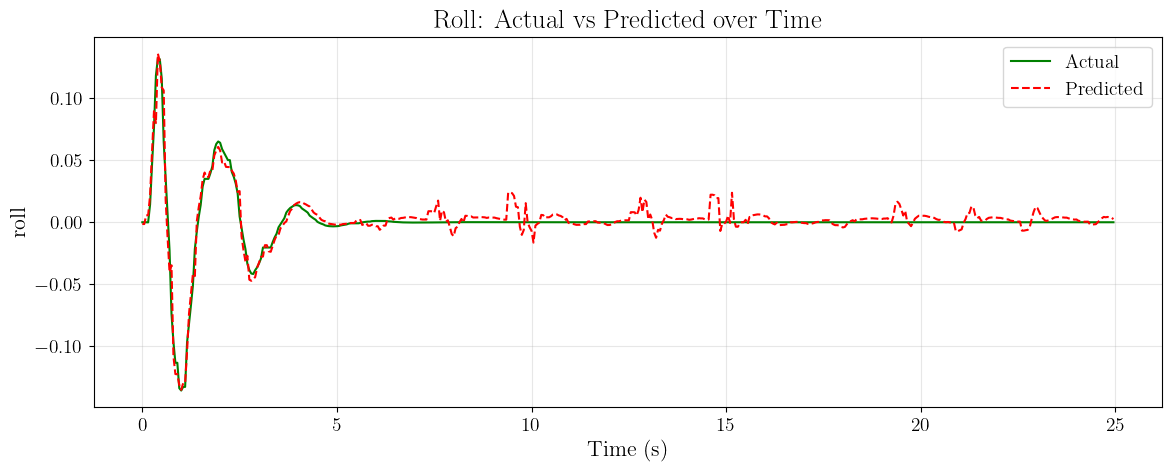

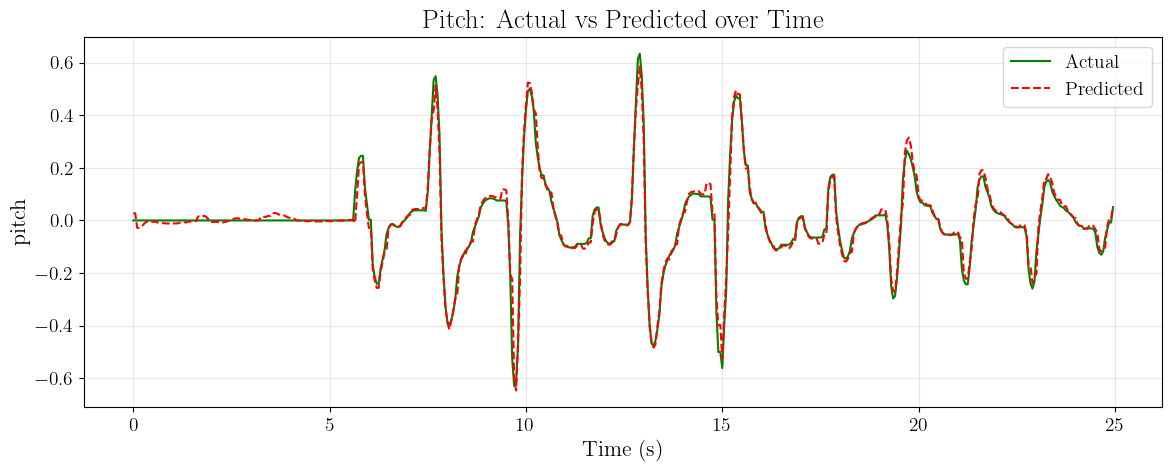

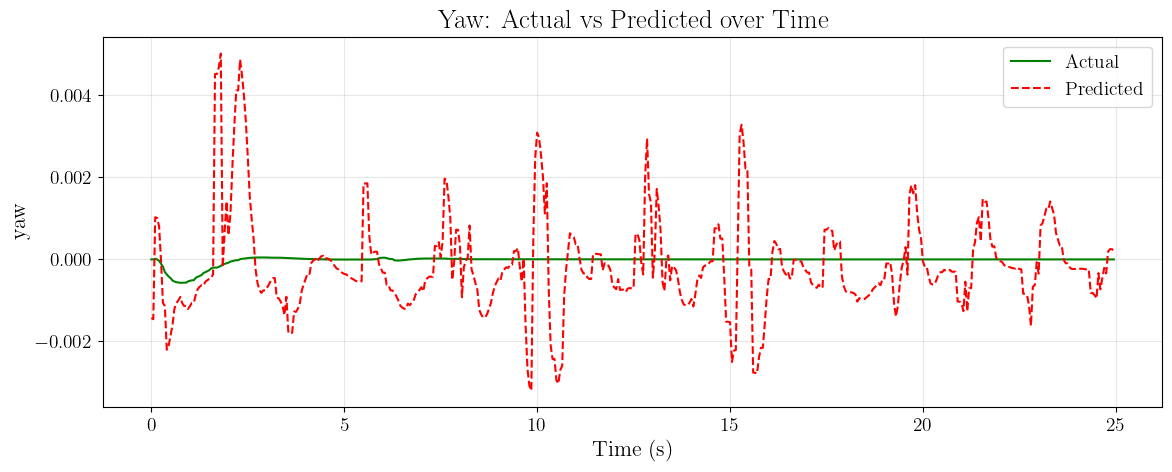

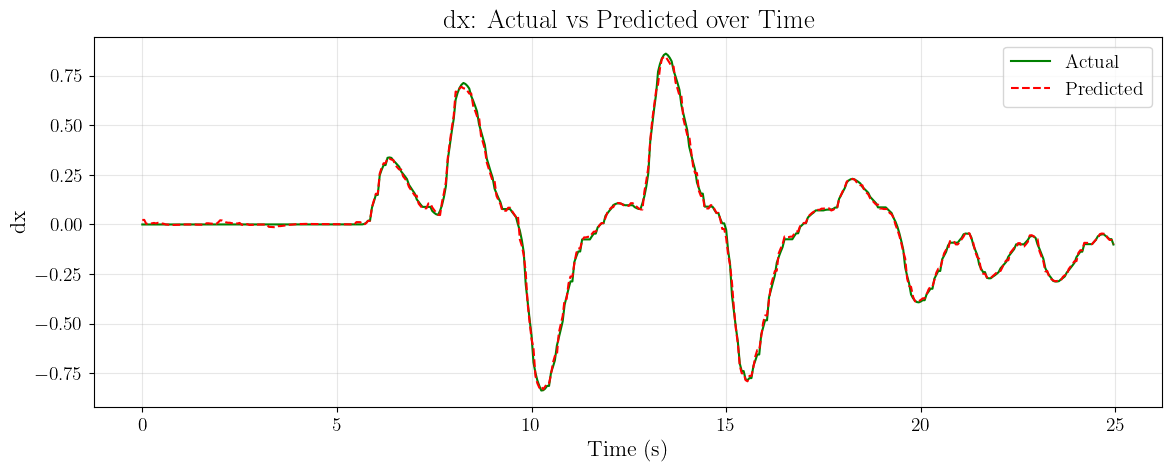

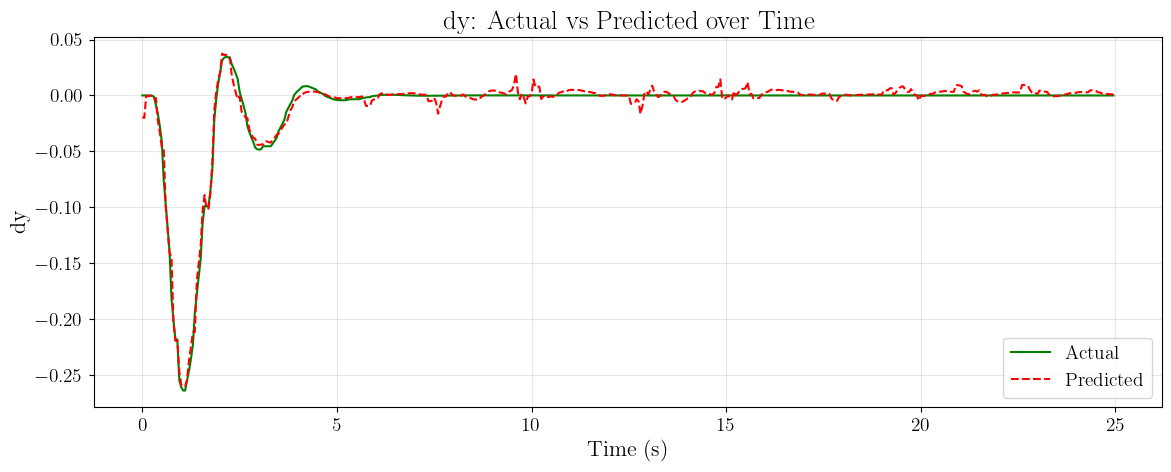

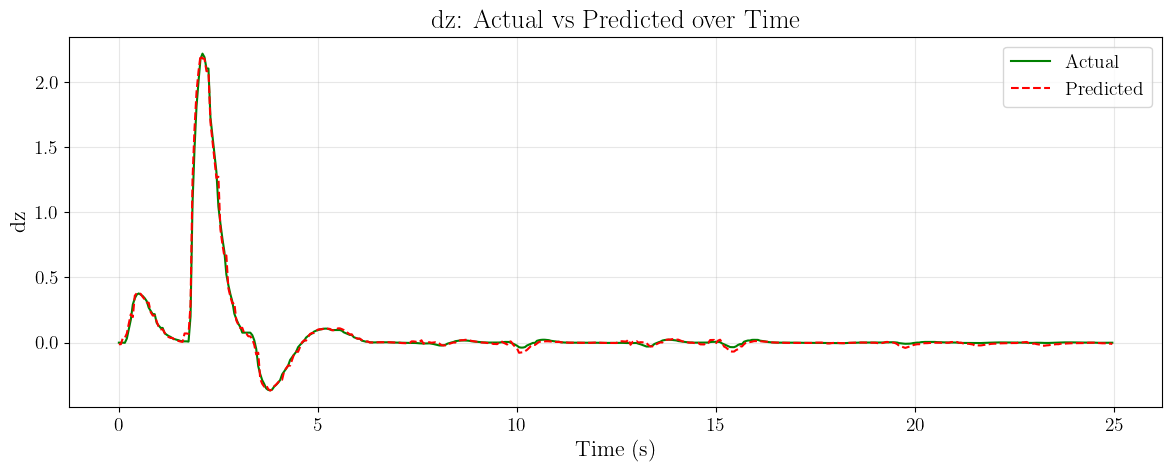

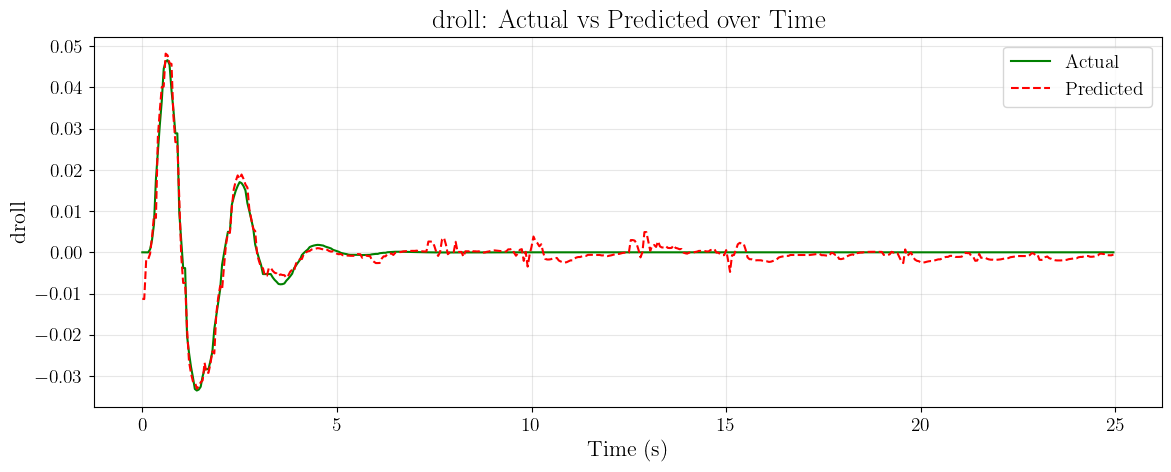

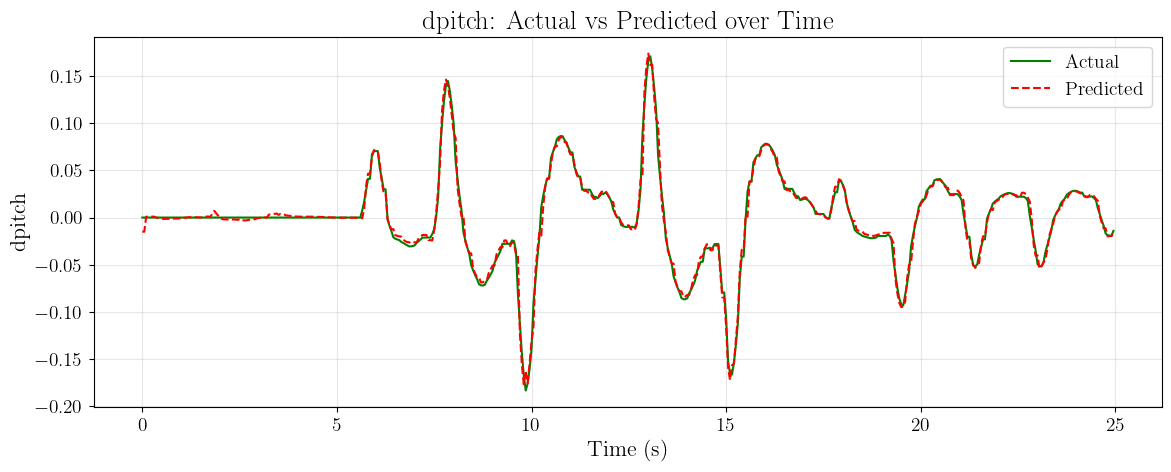

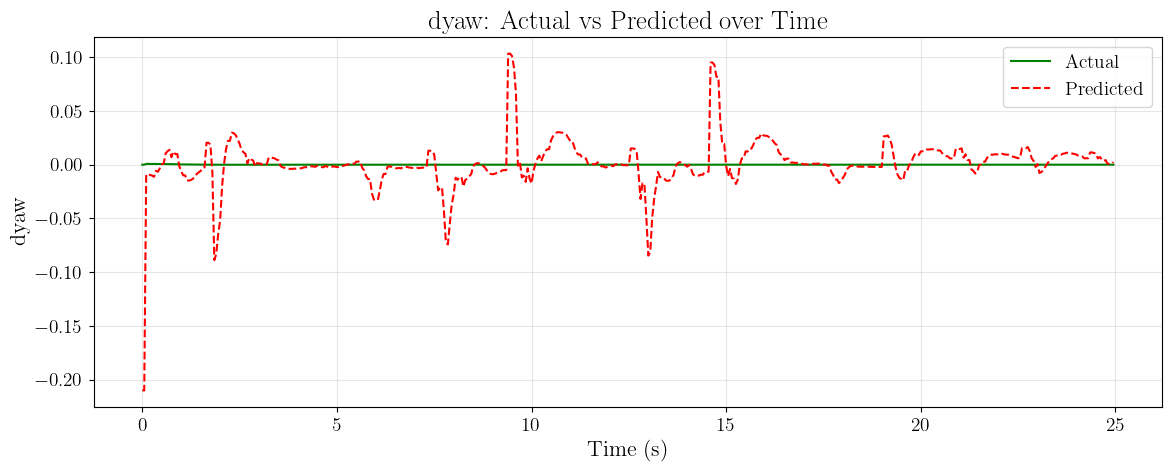

In [11]:
# Utility: plot actual vs predicted observation over time
import matplotlib.pyplot as plt

def plot_observation_vs_time(time_steps, actual_series, predicted_series, ylabel="obs", title="Observation vs Time"):
    """
    Plots actual (ground-truth) observation and predicted observation vs time.

    Args:
        time_steps (Sequence[float]): time values (s)
        actual_series (Sequence[float]): ground-truth observation values
        predicted_series (Sequence[float]): model-predicted observation values
        ylabel (str): y-axis label for the observation name
        title (str): plot title
    """
    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, actual_series, 'g-', linewidth=1.5, label='Actual')
    plt.plot(time_steps, predicted_series, 'r--', linewidth=1.5, label='Predicted')
    plt.xlabel('Time (s)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage (uncomment and adapt lists you already computed):
plot_observation_vs_time(time_steps, roll_actual, roll_predicted, ylabel='roll', title='Roll: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, pitch_actual, pitch_predicted, ylabel='pitch', title='Pitch: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, yaw_actual, yaw_predicted, ylabel='yaw', title='Yaw: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dx_actual, dx_predicted, ylabel='dx', title='dx: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dy_actual, dy_predicted, ylabel='dy', title='dy: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dz_actual, dz_predicted, ylabel='dz', title='dz: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, droll_actual, droll_predicted, ylabel='droll', title='droll: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dpitch_actual, dpitch_predicted, ylabel='dpitch', title='dpitch: Actual vs Predicted over Time')
plot_observation_vs_time(time_steps, dyaw_actual, dyaw_predicted, ylabel='dyaw', title='dyaw: Actual vs Predicted over Time')




In [2]:
# Compute stats (mean, variance, std, min, max) of actions in rpy_0_05_combined_replay_buffer
import torch
import numpy as np

assert 'rpy_0_05_combined_replay_buffer' in globals(), "Run the data loading cell to build rpy_0_05_combined_replay_buffer."

actions = []
for tr in rpy_0_05_combined_replay_buffer:
    _, action, _, _, _, _ = tr
    a = torch.as_tensor(action, dtype=torch.float32)
    if a.ndim == 0:
        a = a.unsqueeze(0)
    actions.append(a)

if len(actions) == 0:
    raise RuntimeError("No actions found in rpy_0_05_combined_replay_buffer.")

actions_tensor = torch.stack(actions, dim=0)

mean = actions_tensor.mean(dim=0)
var = actions_tensor.var(dim=0, unbiased=False)
std = actions_tensor.std(dim=0, unbiased=False)
mins = actions_tensor.min(dim=0).values
maxs = actions_tensor.max(dim=0).values

mean_np = mean.cpu().numpy()
var_np = var.cpu().numpy()
std_np = std.cpu().numpy()
mins_np = mins.cpu().numpy()
maxs_np = maxs.cpu().numpy()

names = ['thrust', 'roll_cmd', 'pitch_cmd', 'yaw_cmd']
print("Action statistics (over N={} samples):".format(actions_tensor.shape[0]))
for i in range(actions_tensor.shape[1]):
    label = names[i] if i < len(names) else f"action[{i}]"
    print(f"- {label}: mean={mean_np[i]:.6f}, var={var_np[i]:.6f}, std={std_np[i]:.6f}, min={mins_np[i]:.6f}, max={maxs_np[i]:.6f}")


Action statistics (over N=205588 samples):
- thrust: mean=3.266839, var=0.288206, std=0.536848, min=-3.687469, max=9.151173
- roll_cmd: mean=-0.000024, var=0.002194, std=0.046839, min=-0.720032, max=0.729747
- pitch_cmd: mean=0.000000, var=0.000007, std=0.002566, min=-0.044539, max=0.044809
- yaw_cmd: mean=-0.000011, var=0.000032, std=0.005651, min=-0.103701, max=0.097544
